# Climate DT and ERA5

In this exercise we will download ERA5 data and compare it to Climate DT data.

TO DO, edit this text: CMIP6 is the [Climate Model Intercomparison Project Phase 6](https://wcrp-cmip.org/cmip-phases/cmip6/) which includes many different model experiments, mostly with resoltions coarser than 100km. These experiments can be a interesting to use as a reference point for current lower resolution models. Comparing to those one can see where we can benefit from high-resolution data but also where resolution increases do not solve all issues in climate models. In this exercise we will look at the Uusimaa area as the example of a metropolitan area where climate adaptation on the local scale can profit from high-resolution data.

**Steps in this exercise:**  
- Download ERA5 data selection
- Download a data selection of the Climate DT SSP3-7.0 simulations
- Regrid standard resolution healpix data to ERA5 grid
- Compare variable X and Y of Climate DT to the multi-model mean of CMIP6
- 

## Downloading monthly ClimateDT data




### Required Packages

Install the following packages before running the cells below:

```bash
pip install intake intake-esm xarray zarr gcsfs pandas matplotlib cartopy
```

| Package | Purpose |
|---|---|
| `intake` | Data catalogue framework |
| `intake-esm` | ESM (Earth System Model) catalogue extension for CMIP6 |
| `xarray` | N-dimensional labelled arrays and datasets |
| `zarr` | Chunked, compressed array storage (format used by Pangeo) |
| `gcsfs` | Google Cloud Storage filesystem access |
| `pandas` | Tabular data handling for catalogue queries |
| `matplotlib` | Plotting |
| `cartopy` | Geospatial projections and map plotting |

In [2]:
import earthkit
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

### Step 1: 

Make a polytope request for the variable avg_sdswrf (Time-mean surface downward short-wave radiation flux) (W / m2),
as a monthly mean from June, 2000.

In [4]:
address="polytope.lumi.apps.dte.destination-earth.eu"

request = {
     'activity': 'baseline',
     'class': 'd1',
     'dataset': 'climate-dt',
     'experiment': 'hist',
     'expver': '0001',
     'model': 'ifs-fesom',
     'generation': '2',
     'realization': '1',
     'resolution': 'high',
     'year': '2000',
     'month': '6',
     'stream': 'clmn',
     'type': 'fc',
     'levtype': 'sfc',
     'param': '235035',
}

## Gets data to memory
data = earthkit.data.from_source(
    "polytope",
    "destination-earth",
    request,
    stream=False,
    address = address
)

## save to file
#data.to_target("file","IFS-FESOM-monthly-hist-2000-06-sdswrf.grib")


2026-06-09 16:15:30 - INFO - Key read from /home/anttivar/.polytopeapirc
2026-06-09 16:15:30 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            "month: '6'\n"
            "param: '235035'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clmn\n'
            'type: fc\n'
            "year: '2000'\n",
 'verb': 'retrieve'}
2026-06-09 16:15:30 - INFO - Polytope user key found in session cache for user anttivar
2026-06-09 16:15:30 - INFO - Request accepted. Please poll ./c6d7e14c-0ba6-4d85-ab90-19a5f8dd8355 for status
2026-06-09 16:15:30 - INFO - Polytope user key found in session cache for user anttivar
2026-06-09 16:15:30 - INFO - Checking request status (c6d7e14c-0ba6-4d85-ab90-19a5f8dd8355)...
2026-06-09 16:

c6d7e14c-0ba6-4d85-ab90-19a5f8dd8355.grib:   0%|          | 0.00/24.9M [00:00<?, ?B/s]

### Step 2: Load both datasets (ERA5 and ClimateDT) into xarray




In [16]:
import cfgrib

era5_file = 'ERA5-monthly-2000-06-ssrd.grib'

ds = data.to_xarray()


#era5_ds = cfgrib.open_datasets(era5_file) # <- another option
era5_ds = xr.open_dataset(era5_file, engine = "cfgrib")
#era5_ds
#ds["avg_sdswrf"].values

array([239.40637207, 240.32025146, 238.81991577, ..., 235.91897583,
       234.93338013, 235.28311157], shape=(12582912,))

### Step 3: Plot the HEALPix data

Use the hp.mollview() function to produce a Mollweide projection view of the HEALPix data. This is an easy way to get a quick look at the data without having to interpolate it to a lon-lat grid.

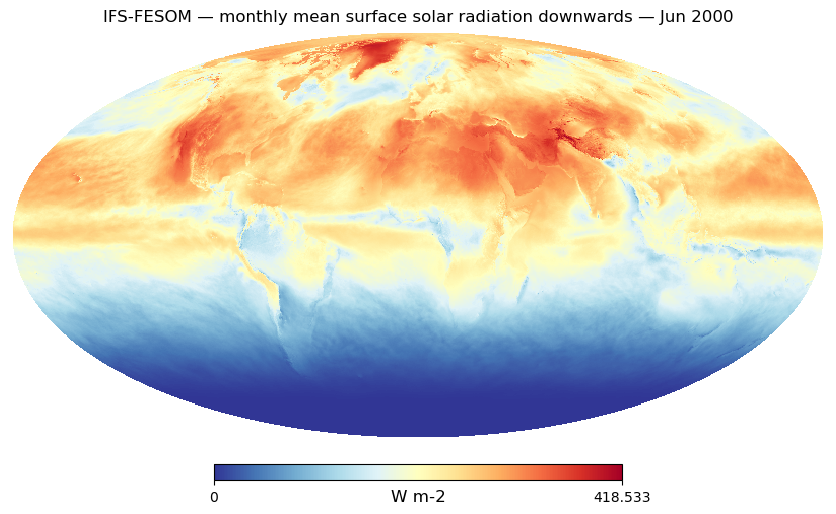

In [24]:
import healpy as hp

hp.mollview(ds["avg_sdswrf"].values, title="IFS-FESOM — monthly mean surface solar radiation downwards — Jun 2000",
            unit="W m-2", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

### Step 4: Changing the zoom level of HEALPix data

Utilize the hierarchical nature of HEALPix to decrease the resolution of the data by changing the Nside values. For example, choose the Nside value that corresponds to a resolution of about 200 km on Earth (see the slides). Plot the resulting map.
(hint: you can use hp.pixelfunc.ud_grade()).

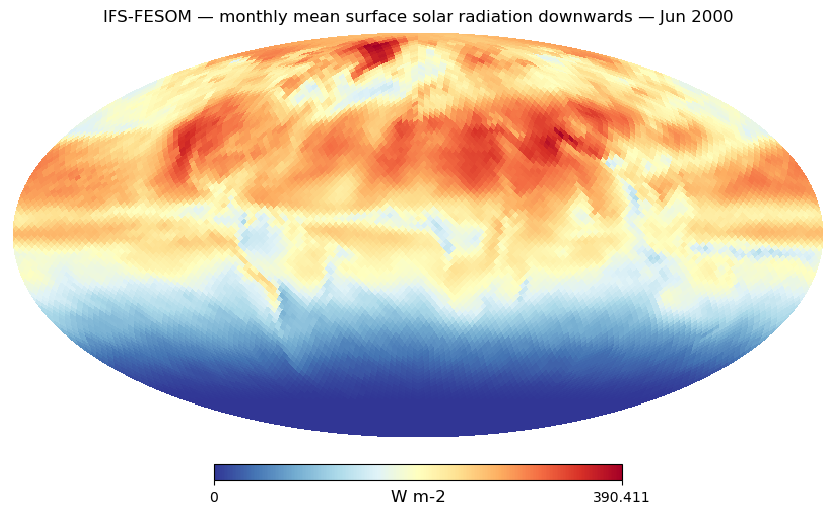

In [28]:
map_128 = hp.pixelfunc.ud_grade(ds["avg_sdswrf"].values, nside_out=32, order_in="NEST")
hp.mollview(map_128, title="IFS-FESOM — monthly mean surface solar radiation downwards — Jun 2000",
            unit="W m-2", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

In [30]:
### Step 5: Interpolate the data and con

In [ ]:
data_regrid = ekd.from_source("polytope", "destination-earth", request_regrid, stream=False, \
                               address='polytope.mn5.apps.dte.destination-earth.eu')

### Step 6: Calculating bias

Calculate the bias between the two datasets (ClimateDT - ERA5)

In [ ]:
# Save each model's southern Finland subset to a separate NetCDF file
for key, ds in dset_finland.items():
    # key format: "activity_id.institution_id.source_id.experiment_id...."
    source_id = ds.attrs.get("source_id", key.split(".")[2])
    out_path = f"cmip6_tas_southern_finland_{source_id}.nc"
    ds.compute().to_netcdf(out_path)
    print(f"Saved {out_path}")

### Step 6: Quick Verification Plot

Plot the spatial mean temperature time series for all models to verify the download looks sensible before proceeding with the comparison.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

for key, ts in timeseries.items():
    source_id = key.split(".")[2]
    # Convert from Kelvin to Celsius
    ax.plot(ts.time.values, ts.values - 273.15, label=source_id, alpha=0.7, linewidth=0.8)

ax.set_title("CMIP6 SSP2-4.5 — Near-surface Temperature, Southern Finland")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Year")
ax.legend(fontsize=7, ncol=3, loc="upper left")
plt.tight_layout()
plt.show()